In [1]:
### pip install pystan
### conda install -c conda-forge fbprophet
!pip install prophet
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
df=pd.read_csv('/content/features.csv')

In [3]:
df.head()

,Date,Fuel_Price
0,05-02-2010,2.572
1,12-02-2010,2.548
2,19-02-2010,2.514
3,26-02-2010,2.561
4,05-03-2010,2.625


In [4]:
df.tail()

,Date,Fuel_Price
8185,28-06-2013,3.639
8186,05-07-2013,3.614
8187,12-07-2013,3.614
8188,19-07-2013,3.737
8189,26-07-2013,3.804


<Axes: >

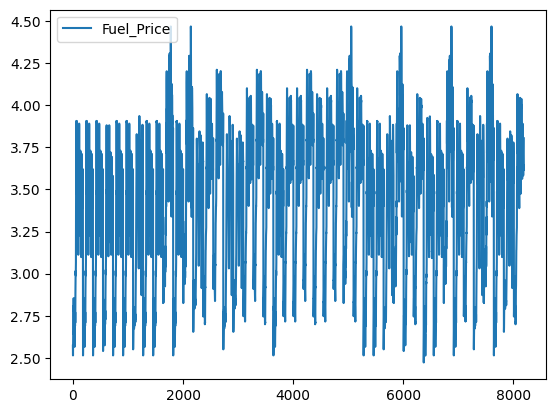

In [5]:
df.plot()

In [6]:
df.columns = ['ds','y']
df.head()

,ds,y
0,05-02-2010,2.572
1,12-02-2010,2.548
2,19-02-2010,2.514
3,26-02-2010,2.561
4,05-03-2010,2.625


In [7]:
df.drop(144,axis=0,inplace=True)

In [8]:
df.tail()

,ds,y
8185,28-06-2013,3.639
8186,05-07-2013,3.614
8187,12-07-2013,3.614
8188,19-07-2013,3.737
8189,26-07-2013,3.804


In [10]:
df['ds'] = pd.to_datetime(df['ds'], format='%d-%m-%Y')

In [11]:
df.head()

,ds,y
0,2010-02-05,2.572
1,2010-02-12,2.548
2,2010-02-19,2.514
3,2010-02-26,2.561
4,2010-03-05,2.625


In [12]:
df.tail()

,ds,y
8185,2013-06-28,3.639
8186,2013-07-05,3.614
8187,2013-07-12,3.614
8188,2013-07-19,3.737
8189,2013-07-26,3.804


In [13]:
# Initialize the Model
model=Prophet()

In [14]:
df.columns

Index(['ds', 'y'], dtype='object')

In [15]:
df.dropna(axis=0,inplace=True)
df.head()

,ds,y
0,2010-02-05,2.572
1,2010-02-12,2.548
2,2010-02-19,2.514
3,2010-02-26,2.561
4,2010-03-05,2.625


In [16]:
model.fit(df)

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [17]:
model.component_modes

{'additive': ['yearly',
  'additive_terms',
  'extra_regressors_additive',
  'holidays'],
 'multiplicative': ['multiplicative_terms', 'extra_regressors_multiplicative']}

In [18]:
df.tail()

,ds,y
8185,2013-06-28,3.639
8186,2013-07-05,3.614
8187,2013-07-12,3.614
8188,2013-07-19,3.737
8189,2013-07-26,3.804


In [19]:
### Create future dates of 365 days
future_dates=model.make_future_dataframe(periods=365)

In [20]:
future_dates.tail()

,ds
542,2014-07-22
543,2014-07-23
544,2014-07-24
545,2014-07-25
546,2014-07-26


In [21]:
prediction=model.predict(future_dates)

In [22]:
prediction.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2010-02-05,2.791171,2.383905,2.826010,2.791171,2.791171,-0.188961,-0.188961,-0.188961,-0.188961,-0.188961,-0.188961,0.0,0.0,0.0,2.602211
1,2010-02-12,2.789020,2.402887,2.865618,2.789020,2.789020,-0.147895,-0.147895,-0.147895,-0.147895,-0.147895,-0.147895,0.0,0.0,0.0,2.641125
2,2010-02-19,2.786868,2.463388,2.935691,2.786868,2.786868,-0.097061,-0.097061,-0.097061,-0.097061,-0.097061,-0.097061,0.0,0.0,0.0,2.689807
3,2010-02-26,2.784716,2.513859,2.975878,2.784716,2.784716,-0.040646,-0.040646,-0.040646,-0.040646,-0.040646,-0.040646,0.0,0.0,0.0,2.744069
4,2010-03-05,2.782564,2.568879,3.030174,2.782564,2.782564,0.011780,0.011780,0.011780,0.011780,0.011780,0.011780,0.0,0.0,0.0,2.794344


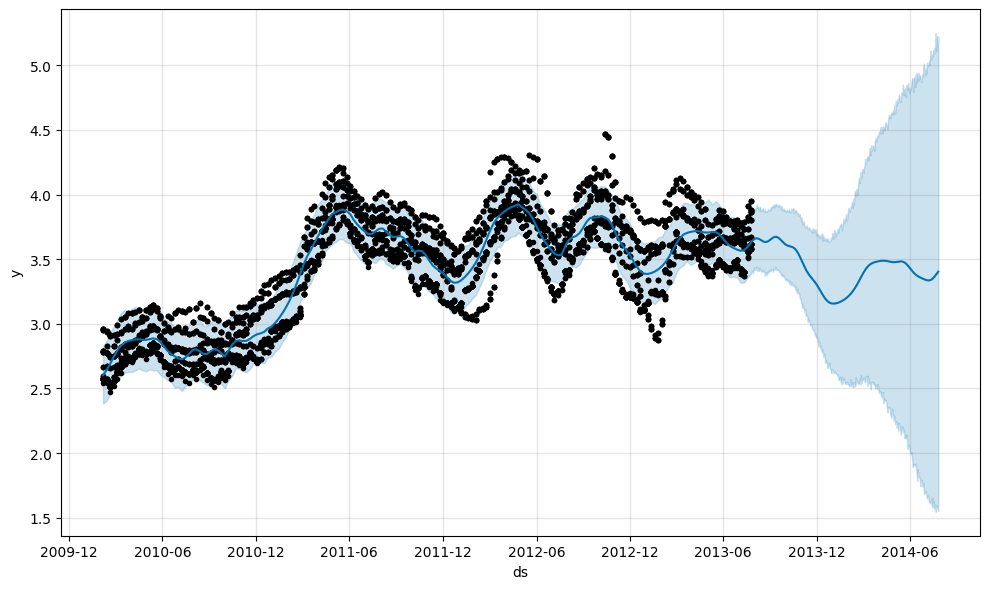

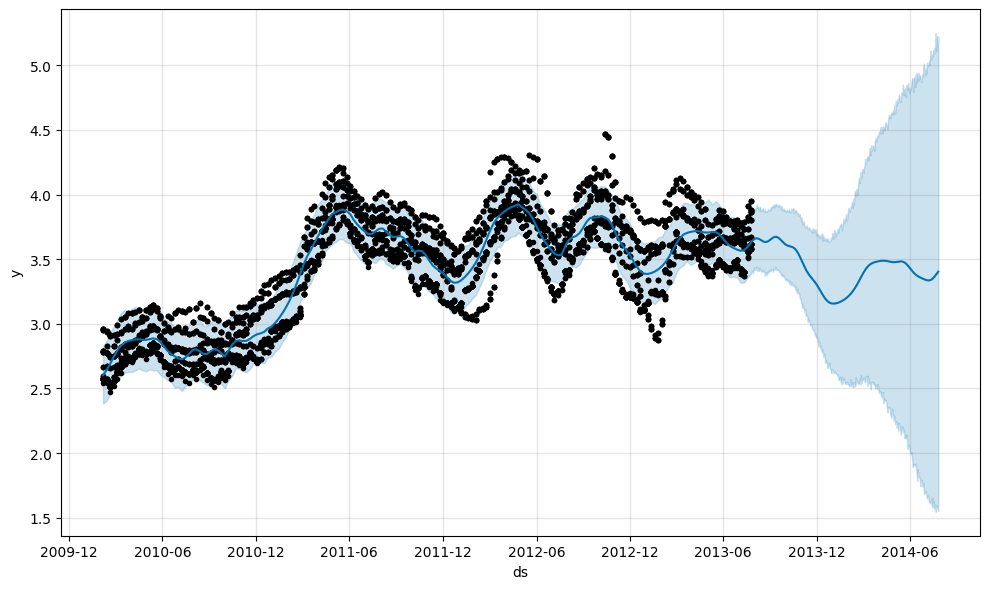

In [23]:
### plot the predicted projection
model.plot(prediction)

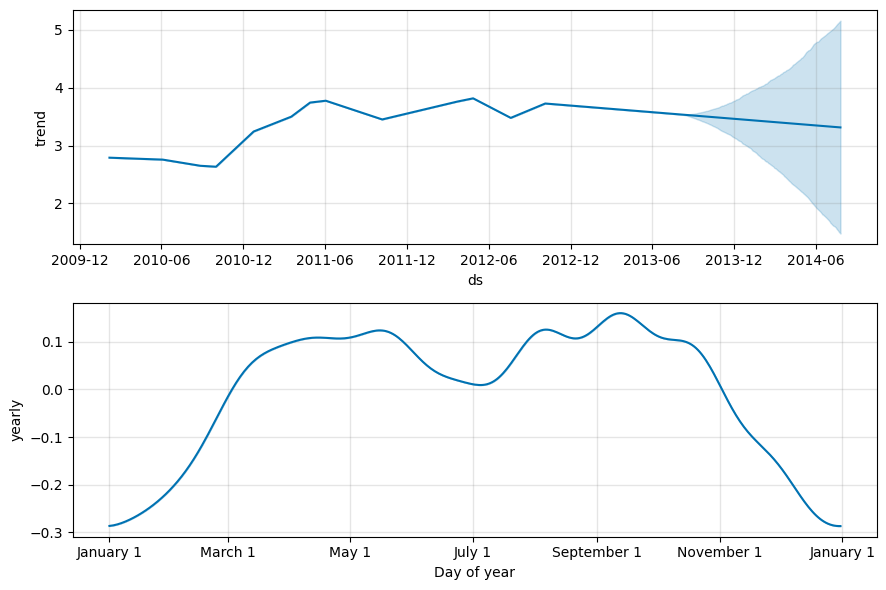

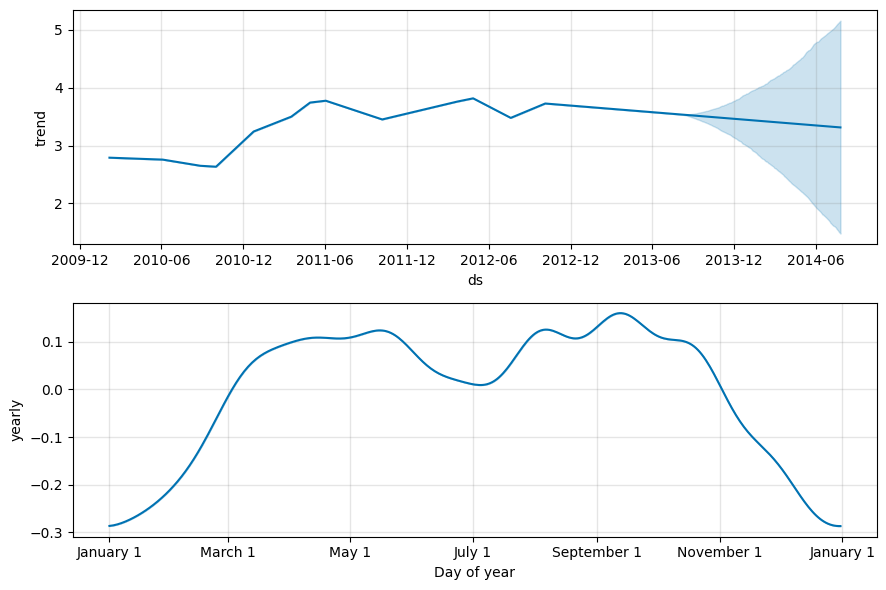

In [24]:
#### Visualize Each Components[Trends,yearly]
model.plot_components(prediction)

In [25]:
#Time Series Analysis

1960-1962
#Cross Validation
1960-61 #Train dataset
1961-62 #Test dataset
1962-63 #Validation

1899

In [26]:
df.head()

,ds,y
0,2010-02-05,2.572
1,2010-02-12,2.548
2,2010-02-19,2.514
3,2010-02-26,2.561
4,2010-03-05,2.625


In [27]:
from prophet.diagnostics import cross_validation
df_cv = cross_validation(model, initial='730 days', period='180 days', horizon = '365 days')
df_cv.head()

INFO:prophet:Making 1 forecasts with cutoffs between 2012-07-26 00:00:00 and 2012-07-26 00:00:00


  0%|          | 0/1 [00:00<?, ?it/s]

,ds,yhat,yhat_lower,yhat_upper,y,cutoff
0,2012-07-27,3.469805,3.250615,3.683915,3.407,2012-07-26
1,2012-07-27,3.469805,3.243776,3.684411,3.407,2012-07-26
2,2012-07-27,3.469805,3.253663,3.683388,3.407,2012-07-26
3,2012-07-27,3.469805,3.271146,3.685836,3.356,2012-07-26
4,2012-07-27,3.469805,3.243631,3.683275,3.407,2012-07-26


In [28]:
from prophet.diagnostics import performance_metrics
df_p = performance_metrics(df_cv)
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,0.149891,0.387157,0.325994,0.086075,0.086645,0.091458,0.320915
1,43 days,0.212113,0.460557,0.407246,0.106562,0.099374,0.114152,0.190103
2,50 days,0.276079,0.525432,0.485447,0.126243,0.124856,0.136094,0.079552
3,57 days,0.350714,0.592211,0.557772,0.143899,0.139619,0.156319,0.014566
4,64 days,0.406362,0.637465,0.607849,0.156372,0.151191,0.170796,0.000000


In [29]:
df_p.head()

,horizon,mse,rmse,mae,mape,mdape,smape,coverage
0,36 days,0.149891,0.387157,0.325994,0.086075,0.086645,0.091458,0.320915
1,43 days,0.212113,0.460557,0.407246,0.106562,0.099374,0.114152,0.190103
2,50 days,0.276079,0.525432,0.485447,0.126243,0.124856,0.136094,0.079552
3,57 days,0.350714,0.592211,0.557772,0.143899,0.139619,0.156319,0.014566
4,64 days,0.406362,0.637465,0.607849,0.156372,0.151191,0.170796,0.000000


/usr/local/lib/python3.12/dist-packages/prophet/plot.py:547: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt = df_none['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])
/usr/local/lib/python3.12/dist-packages/prophet/plot.py:548: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  x_plt_h = df_h['horizon'].astype('timedelta64[ns]').view(np.int64) / float(dt_conversions[i])


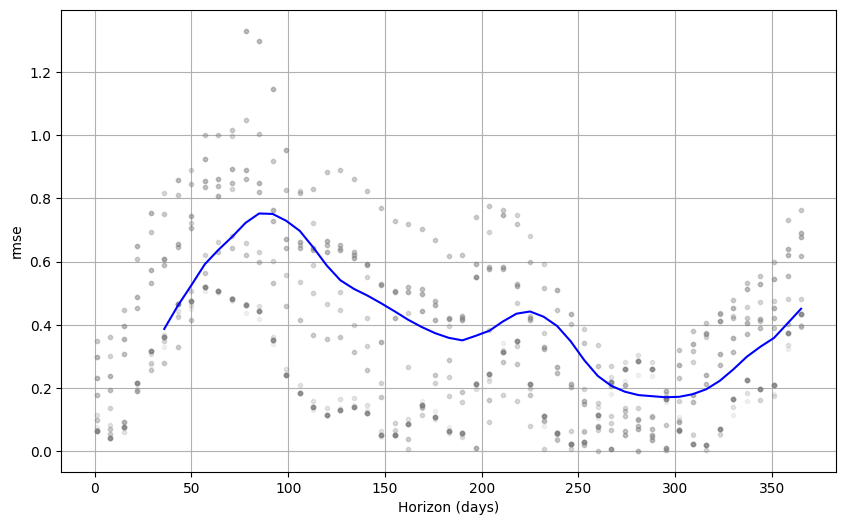

In [30]:
from prophet.plot import plot_cross_validation_metric
fig = plot_cross_validation_metric(df_cv, metric='rmse')